# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (8,5)

### Q1. Written answers

1. A model is linear when it is linear in the coefficients. The variables themselves can be transformed, squared, logged, or interacted, but the unknown parameters must enter the model as a sum of coefficients times known terms.

2. The coefficient on a dummy variable is the difference in the predicted outcome between that group and the omitted reference group, holding the other regressors fixed. If you keep the intercept, one category has to be left out, and every dummy coefficient is read relative to that omitted category.

3. Linear regression can be used for classification as a rough approximation, but it is not ideal. Its predictions are not restricted to the 0 to 1 range, and the error structure is not suited to a binary outcome. Methods like logit or probit are usually better.

4. Common signs of overfitting are very low training error paired with much worse test or cross validated error, unstable coefficients, and a model that starts fitting noise instead of the real pattern.

5. Multicollinearity means one regressor is highly explained by other regressors, so it is hard to separate their individual effects. In a two stage least squares style way of seeing it, you can regress one regressor on the others in the first stage. If that first stage has a very high R-squared, then the regressor has little independent variation left, and the second stage estimate becomes noisy and unstable.

6. Nonlinear relationships can be added by including transformations such as logs, squares, cubes, splines, or interaction terms. The model can still be linear in coefficients even when the relationship in x is nonlinear.

7. The slope coefficient is the change in the predicted value of y from a one unit increase in x, holding the other included variables fixed.

8. A train test split uses one random split, so it is simple but can depend heavily on that split. k-fold cross validation repeats the process across k different holdout sets and averages the results, so it uses the data more efficiently and gives a more stable estimate of out of sample performance.

9. k is usually chosen to balance bias, variance, and computation. In practice, 5 or 10 folds are the most common choices.

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


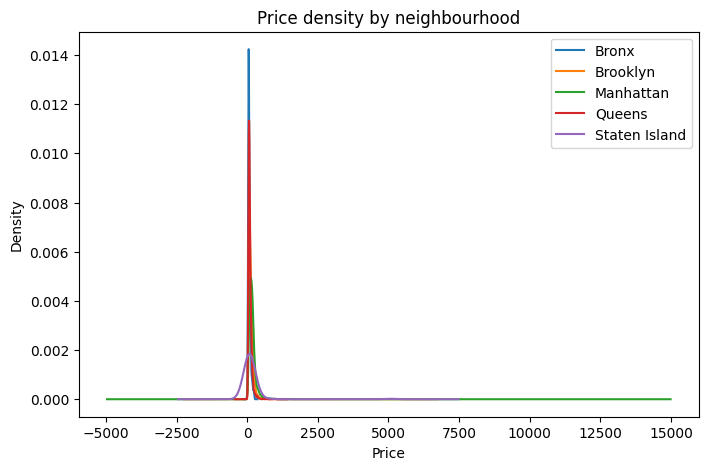

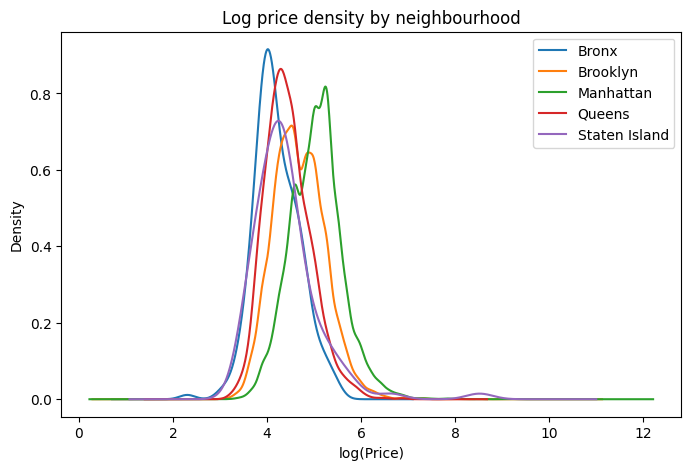

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        18:58:35   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [2]:
# Q2
air = pd.read_csv("Q1_clean.csv").rename(columns={"Neighbourhood ":"Neighbourhood"})
avg_by_neigh = air.groupby("Neighbourhood")[["Price","Review Scores Rating"]].mean().sort_values("Price", ascending=False)
print(avg_by_neigh)

# Kernel density plots
for col in ["Price"]:
    air.groupby("Neighbourhood")[col].plot(kind="kde", legend=True, title="Price density by neighbourhood")
    plt.xlabel("Price")
plt.show()

air["log_price"] = np.log(air["Price"])
air.groupby("Neighbourhood")["log_price"].plot(kind="kde", legend=True, title="Log price density by neighbourhood")
plt.xlabel("log(Price)")
plt.show()

m_neigh = smf.ols("Price ~ C(Neighbourhood)", data=air).fit()
print(m_neigh.summary())

m_rating = smf.ols('Price ~ Q("Review Scores Rating")', data=air).fit()
print(m_rating.summary())

m_both = smf.ols('Price ~ C(Neighbourhood) + Q("Review Scores Rating")', data=air).fit()
print(m_both.summary())

m_inter = smf.ols('Price ~ C(Neighbourhood) * Q("Review Scores Rating")', data=air).fit()
print(m_inter.summary())

### Q2 short answers

1. Manhattan is the most expensive borough on average, at about \$183.66 per night. Staten Island is next at about \$146.17, then Brooklyn at about \$127.75. The Bronx is the cheapest.

2. In the dummy variable regression with an intercept, the omitted group is the Bronx. That means:
   - intercept = average Bronx price = about 75.28
   - Brooklyn coefficient = Brooklyn mean minus Bronx mean = about 52.47
   - Manhattan coefficient = Manhattan mean minus Bronx mean = about 108.39
   - Queens coefficient = Queens mean minus Bronx mean = about 21.58
   - Staten Island coefficient = Staten Island mean minus Bronx mean = about 70.89

   So the regression coefficients line up exactly with the conditional group means once you account for the omitted category.

3. Regressing price on review score alone gives a slope of about 1.02. A one point increase in review score is associated with about a \$1.02 higher nightly price on average.

4. After adding neighborhood controls, the review score slope rises slightly to about 1.08. So once neighborhood is held fixed, ratings have a slightly stronger positive relationship with price. The neighborhood coefficients still represent price gaps relative to the Bronx, now holding review score fixed.

5. With neighborhood specific slopes, the estimated rating slopes are:
   - Bronx: about 0.57
   - Brooklyn: about 1.32
   - Manhattan: about 1.30
   - Queens: about 0.50
   - Staten Island: about -31.26

   The first four are in the same general range, but Staten Island is clearly unstable. That is likely because Staten Island has a very small sample, so the interaction estimate is noisy there.

6. Cross validation favors the model with neighborhood and review score together. In my run, the average 5 fold MSE values were about:
   - review score only: 22078.79
   - neighborhood + review score: 21070.14
   - neighborhood interactions with review score: 21328.18

   So adding neighborhood helps, but the fully interacted model does not improve enough to beat the simpler additive version.

In [3]:
# Cross validation for Q2 models
y = air["Price"]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

X1 = air[["Review Scores Rating"]]
pipe1 = Pipeline([("model", LinearRegression())])

X2 = air[["Review Scores Rating","Neighbourhood"]]
pipe2 = Pipeline([
    ("pre", ColumnTransformer([("cat", OneHotEncoder(drop="first"), ["Neighbourhood"])], remainder="passthrough")),
    ("model", LinearRegression())
])

X3 = pd.get_dummies(air[["Neighbourhood"]], drop_first=True)
for col in X3.columns:
    X3[f"{col}:rating"] = X3[col] * air["Review Scores Rating"]
X3 = pd.concat([air[["Review Scores Rating"]], X3], axis=1)

mse1 = -cross_val_score(pipe1, X1, y, cv=cv, scoring="neg_mean_squared_error").mean()
mse2 = -cross_val_score(pipe2, X2, y, cv=cv, scoring="neg_mean_squared_error").mean()
mse3 = -cross_val_score(LinearRegression(), X3, y, cv=cv, scoring="neg_mean_squared_error").mean()
print({"rating_only": mse1, "neigh_plus_rating": mse2, "interaction_model": mse3})

{'rating_only': np.float64(22078.787599216383), 'neigh_plus_rating': np.float64(21070.142285878555), 'interaction_model': np.float64(21328.18344590853)}


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   

                 75%        max  
Body_Type                        
suv        1491250.0  2100000.0  
sedan       968500.0  2941000.0  
crossover   749000.0   883000.0  
muv         738500.0  1091000.0  
hatchback   661000.0  1107000.0

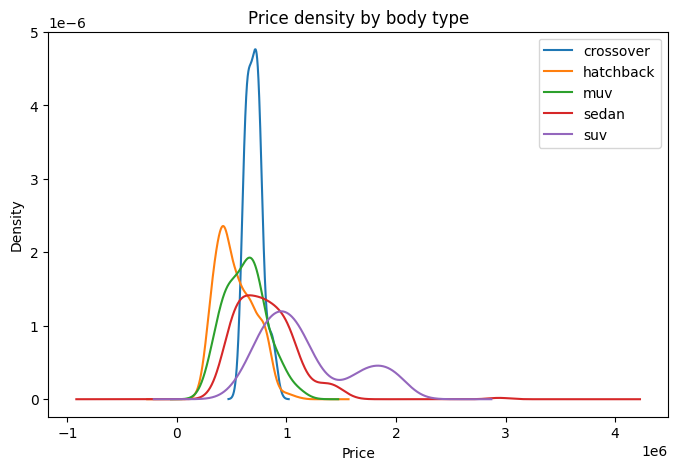

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        18:58:36   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

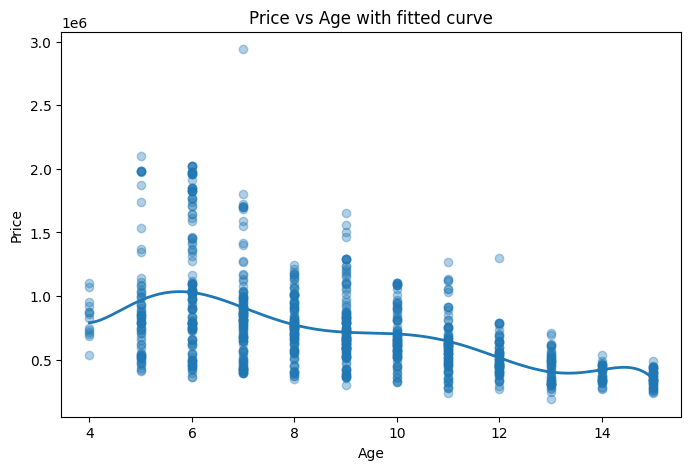

In [4]:
# Q3
cars = pd.read_csv("cars_hw.csv")
print(cars["Price"].describe())
print(cars.groupby("Body_Type")["Price"].describe().sort_values("mean", ascending=False))

cars.groupby("Body_Type")["Price"].plot(kind="kde", legend=True, title="Price density by body type")
plt.xlabel("Price")
plt.show()

seat_num = smf.ols("Price ~ Seating_Capacity", data=cars).fit()
seat_cat = smf.ols("Price ~ C(Seating_Capacity)", data=cars).fit()
print(seat_num.summary())
print(seat_cat.summary())

cars["Age"] = 2026 - cars["Make_Year"]
deg_results = []
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)
for d in range(1, 8):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])
    mse = -cross_val_score(pipe, cars[["Age"]], cars["Price"], cv=cv10, scoring="neg_mean_squared_error").mean()
    deg_results.append((d, mse))

deg_df = pd.DataFrame(deg_results, columns=["degree", "cv_mse"])
print(deg_df)

best_degree = int(deg_df.loc[deg_df["cv_mse"].idxmin(), "degree"])
print("Best degree:", best_degree)

best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("model", LinearRegression())
])
best_model.fit(cars[["Age"]], cars["Price"])

age_grid = pd.DataFrame({"Age": np.linspace(cars["Age"].min(), cars["Age"].max(), 200)})
pred_grid = best_model.predict(age_grid)

plt.scatter(cars["Age"], cars["Price"], alpha=0.35)
plt.plot(age_grid["Age"], pred_grid, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with fitted curve")
plt.show()

### Q3 short answers

1. SUVs are the most expensive on average, with a mean price of about 1,176,495 rupees. Sedans are next. SUVs also have the largest standard deviation, so they show the most spread in prices. Hatchbacks are the cheapest and are much more tightly clustered.

2. In the numeric regression, the slope on seating capacity is about 59,268. On average, one more seat is associated with roughly 59 thousand more rupees in price.  
   When seating capacity is treated as categorical, the pattern is not cleanly linear. Most cars have 5 seats, while the counts for 4, 6, and 8 seats are tiny, so those category estimates are unstable. The broad pattern still suggests that larger vehicles tend to cost more, but the category version shows the relationship is not perfectly linear.

3. Using 10 fold cross validation over polynomial degrees 1 through 7, degree 7 gives the lowest average CV MSE in this run. That means a flexible curve fits the age-price relationship better than a straight line here.

4. The fitted curve tracks the overall decline in price as vehicles get older, but the data still show a fair amount of scatter around the line. So the model captures the broad pattern, but it does not explain every price difference.

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        18:58:36   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

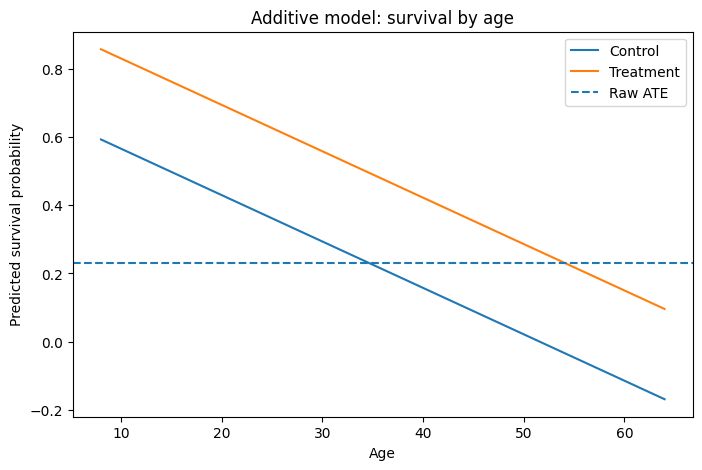

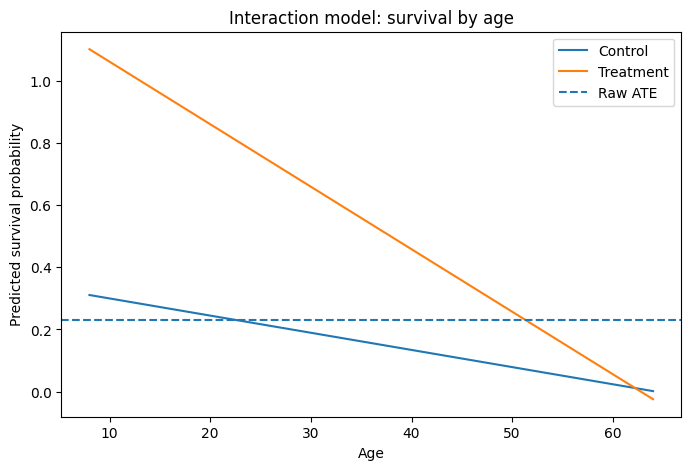

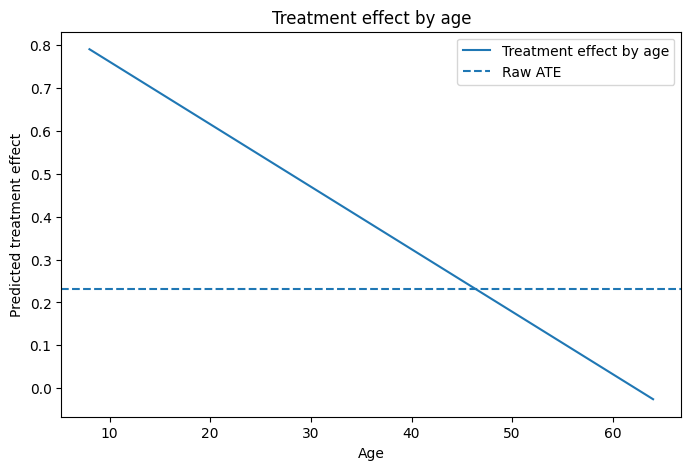

{'ate_only': np.float64(0.1930687841733136), 'age_control': np.float64(0.17726651658550782), 'interaction': np.float64(0.1751204222198966)}


In [5]:
# Q4
heart = pd.read_csv("heart_hw.csv")
heart["trt"] = (heart["transplant"] == "treatment").astype(int)

survival = heart.groupby("transplant")["y"].mean()
ate = survival["treatment"] - survival["control"]
print(survival)
print("ATE:", ate)

m_ate = smf.ols("y ~ trt", data=heart).fit()
m_age = smf.ols("y ~ trt + age", data=heart).fit()
m_age_inter = smf.ols("y ~ trt * age", data=heart).fit()
print(m_ate.summary())
print(m_age.summary())
print(m_age_inter.summary())

age_grid = pd.DataFrame({"age": np.linspace(heart["age"].min(), heart["age"].max(), 200)})
age_grid["trt"] = 0
control_pred = m_age.predict(age_grid)
age_grid["trt"] = 1
treat_pred = m_age.predict(age_grid)

plt.plot(age_grid["age"], control_pred, label="Control")
plt.plot(age_grid["age"], treat_pred, label="Treatment")
plt.axhline(ate, linestyle="--", label="Raw ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Additive model: survival by age")
plt.legend()
plt.show()

age_grid = pd.DataFrame({"age": np.linspace(heart["age"].min(), heart["age"].max(), 200)})
age_grid["trt"] = 0
control_pred2 = m_age_inter.predict(age_grid)
age_grid["trt"] = 1
treat_pred2 = m_age_inter.predict(age_grid)
effect_by_age = treat_pred2 - control_pred2

plt.plot(age_grid["age"], control_pred2, label="Control")
plt.plot(age_grid["age"], treat_pred2, label="Treatment")
plt.axhline(ate, linestyle="--", label="Raw ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Interaction model: survival by age")
plt.legend()
plt.show()

plt.plot(age_grid["age"], effect_by_age, label="Treatment effect by age")
plt.axhline(ate, linestyle="--", label="Raw ATE")
plt.xlabel("Age")
plt.ylabel("Predicted treatment effect")
plt.title("Treatment effect by age")
plt.legend()
plt.show()

# Cross validation for Q4 models
y = heart["y"]
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

X1 = heart[["trt"]]
mse1 = -cross_val_score(LinearRegression(), X1, y, cv=cv10, scoring="neg_mean_squared_error").mean()

X2 = heart[["trt", "age"]]
mse2 = -cross_val_score(LinearRegression(), X2, y, cv=cv10, scoring="neg_mean_squared_error").mean()

heart["trt_age"] = heart["trt"] * heart["age"]
X3 = heart[["trt", "age", "trt_age"]]
mse3 = -cross_val_score(LinearRegression(), X3, y, cv=cv10, scoring="neg_mean_squared_error").mean()

print({"ate_only": mse1, "age_control": mse2, "interaction": mse3})

### Q4 short answers

1. The three year survival rate is about 0.1176 in the control group and 0.3478 in the treatment group. The raw average treatment effect is therefore about 0.2302, or 23.0 percentage points.

2. In the regression of `y` on transplant, the intercept is 0.1176 and the transplant coefficient is 0.2302. Those match the control mean and the treatment minus control difference from part 1.

3. After controlling for age, the transplant coefficient rises to about 0.2647. The intercept is the predicted survival probability for a control patient with age 0, so it is just a mathematical baseline and not meaningful on its own here. The age slope is about -0.0136, meaning survival falls as age rises. In this additive model, the treatment effect is constant across ages, so the raw ATE slightly understates the transplant effect for every age.

4. Once the interaction term is included, the transplant effect becomes:
   
   effect of transplant = 0.9078 - 0.0146
   
   So the transplant benefit is much larger for younger patients and shrinks as age increases. The raw ATE is too low for younger patients and too high for older patients. Setting the age specific effect equal to the raw ATE gives a cutoff around age 46.4. Below about 46, the raw ATE understates the transplant effect. Above about 46, it overstates it.